In [ ]:
import pandas as pd
from google.colab import files

# Upload your CSV file
uploaded = files.upload()

# Get the uploaded filename
file_name = next(iter(uploaded))

# Read the dataset
df = pd.read_csv(file_name)

# Basic information
print("========== DATASET INFORMATION ==========")
print("File name:", file_name)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\n========== COLUMN NAMES ==========")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

print("\n========== FIRST 5 ROWS ==========")
display(df.head())

print("\n========== DATA TYPES ==========")
print(df.dtypes)

print("\n========== MISSING VALUES ==========")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n========== UNIQUE VALUES ==========")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Saving 2020_al_data_kaggle_upload_new_old_syllabi.csv to 2020_al_data_kaggle_upload_new_old_syllabi (1).csv
========== DATASET INFORMATION ==========
File name: 2020_al_data_kaggle_upload_new_old_syllabi (1).csv
Number of rows: 337553
Number of columns: 19

========== COLUMN NAMES ==========
1. index
2. stream
3. Zscore
4. district_rank
5. island_rank
6. al_year
7. sub1
8. sub1_r
9. sub2
10. sub2_r
11. sub3
12. sub3_r
13. cgt_r
14. ge_r
15. syllabus
16. birth_day
17. birth_month
18. birth_year
19. gender

========== FIRST 5 ROWS ==========


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,056,S,new,31,May,2001,female
1,1,ARTS,-.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,032,C,new,13,January,2002,female
2,2,COMMERCE,-.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,050,S,new,16,August,2001,female
3,3,COMMERCE,-.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,034,S,new,16,August,2001,female
4,4,COMMERCE,.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,036,S,new,7,August,2000,female



========== DATA TYPES ==========
index             int64
stream           object
Zscore           object
district_rank    object
island_rank      object
al_year           int64
sub1             object
sub1_r           object
sub2             object
sub2_r           object
sub3             object
sub3_r           object
cgt_r            object
ge_r             object
syllabus         object
birth_day        object
birth_month      object
birth_year       object
gender           object
dtype: object

========== MISSING VALUES ==========
gender    1484
dtype: int64

========== UNIQUE VALUES ==========
index: 337553 unique values
stream: 8 unique values
Zscore: 33891 unique values
district_rank: 8060 unique values
island_rank: 47616 unique values
al_year: 1 unique values
sub1: 51 unique values
sub1_r: 7 unique values
sub2: 60 unique values
sub2_r: 7 unique values
sub3: 60 unique values
sub3_r: 8 unique values
cgt_r: 73 unique values
ge_r: 7 unique values
syllabus: 2 unique values
birth_da

In [ ]:
# ==========================================
# CELL 2 - CLEAN THE DATA
# ==========================================

import pandas as pd
import numpy as np

# Make a copy
clean_df = df.copy()

# ------------------------------------------
# 1. Clean Z-score
# ------------------------------------------

clean_df["Zscore"] = (
    clean_df["Zscore"]
    .astype(str)
    .str.strip()
    .replace(["nan", "None", ""], np.nan)
)

clean_df["Zscore"] = pd.to_numeric(
    clean_df["Zscore"],
    errors="coerce"
)

# ------------------------------------------
# 2. Clean District Rank
# ------------------------------------------

clean_df["district_rank"] = (
    clean_df["district_rank"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

clean_df["district_rank"] = pd.to_numeric(
    clean_df["district_rank"],
    errors="coerce"
)

# ------------------------------------------
# 3. Clean Island Rank
# ------------------------------------------

clean_df["island_rank"] = (
    clean_df["island_rank"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

clean_df["island_rank"] = pd.to_numeric(
    clean_df["island_rank"],
    errors="coerce"
)

# ------------------------------------------
# 4. Clean Birth Date
# ------------------------------------------

clean_df["birth_date"] = pd.to_datetime(
    clean_df["birth_day"].astype(str)
    + " "
    + clean_df["birth_month"].astype(str)
    + " "
    + clean_df["birth_year"].astype(str),
    errors="coerce"
)

# ------------------------------------------
# 5. Clean Gender
# ------------------------------------------

clean_df["gender"] = (
    clean_df["gender"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# ------------------------------------------
# 6. Clean text columns
# ------------------------------------------

text_columns = [
    "stream",
    "sub1",
    "sub1_r",
    "sub2",
    "sub2_r",
    "sub3",
    "sub3_r",
    "cgt_r",
    "ge_r",
    "syllabus"
]

for column in text_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
    )

# ------------------------------------------
# Show cleaned data
# ------------------------------------------

print("Cleaned dataset:")
display(clean_df.head())

print("\nData types after cleaning:")
print(clean_df.dtypes)

print("\nDataset size:")
print(clean_df.shape)

Cleaned dataset:


,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender,birth_date
0,0,ARTS,-0.3550,4336.0,64994.0,2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,056,S,new,31,May,2001,female,2001-05-31
1,1,ARTS,-0.2648,4154.0,62338.0,2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,032,C,new,13,January,2002,female,2002-01-13
2,2,COMMERCE,-0.4760,6910.0,37307.0,2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,050,S,new,16,August,2001,female,2001-08-16
3,3,COMMERCE,-0.1012,5678.0,30449.0,2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,034,S,new,16,August,2001,female,2001-08-16
4,4,COMMERCE,0.6014,3269.0,17010.0,2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,036,S,new,7,August,2000,female,2000-08-07



Data types after cleaning:
index                     int64
stream           string[python]
Zscore                  float64
district_rank           float64
island_rank             float64
al_year                   int64
sub1             string[python]
sub1_r           string[python]
sub2             string[python]
sub2_r           string[python]
sub3             string[python]
sub3_r           string[python]
cgt_r            string[python]
ge_r             string[python]
syllabus         string[python]
birth_day                object
birth_month              object
birth_year               object
gender           string[python]
birth_date       datetime64[ns]
dtype: object

Dataset size:
(337553, 20)


In [ ]:
# ==========================================
# CELL 3 - CREATE SUBJECT DATA
# ==========================================

# Subject 1
subject1 = clean_df[[
    "index",
    "stream",
    "Zscore",
    "district_rank",
    "island_rank",
    "al_year",
    "sub1",
    "sub1_r",
    "syllabus",
    "birth_date",
    "gender"
]].copy()

subject1["subject"] = subject1["sub1"]
subject1["grade"] = subject1["sub1_r"]

# Subject 2
subject2 = clean_df[[
    "index",
    "stream",
    "Zscore",
    "district_rank",
    "island_rank",
    "al_year",
    "sub2",
    "sub2_r",
    "syllabus",
    "birth_date",
    "gender"
]].copy()

subject2["subject"] = subject2["sub2"]
subject2["grade"] = subject2["sub2_r"]

# Subject 3
subject3 = clean_df[[
    "index",
    "stream",
    "Zscore",
    "district_rank",
    "island_rank",
    "al_year",
    "sub3",
    "sub3_r",
    "syllabus",
    "birth_date",
    "gender"
]].copy()

subject3["subject"] = subject3["sub3"]
subject3["grade"] = subject3["sub3_r"]

# Keep common columns
columns = [
    "index",
    "stream",
    "Zscore",
    "district_rank",
    "island_rank",
    "al_year",
    "subject",
    "grade",
    "syllabus",
    "birth_date",
    "gender"
]

subject1 = subject1[columns]
subject2 = subject2[columns]
subject3 = subject3[columns]

# Combine all three subjects
subject_data = pd.concat(
    [subject1, subject2, subject3],
    ignore_index=True
)

print("Original student records:", len(clean_df))
print("Subject performance records:", len(subject_data))

print("\nExpected:")
print("337,553 × 3 =", 337553 * 3)

print("\nFirst 10 records:")
display(subject_data.head(10))

Original student records: 337553
Subject performance records: 1012659

Expected:
337,553 × 3 = 1012659

First 10 records:


,index,stream,Zscore,district_rank,island_rank,al_year,subject,grade,syllabus,birth_date,gender
0,0,ARTS,-0.3550,4336.0,64994.0,2020,POLITICAL SCIENCE,S,new,2001-05-31,female
1,1,ARTS,-0.2648,4154.0,62338.0,2020,POLITICAL SCIENCE,S,new,2002-01-13,female
2,2,COMMERCE,-0.4760,6910.0,37307.0,2020,ECONOMICS,S,new,2001-08-16,female
3,3,COMMERCE,-0.1012,5678.0,30449.0,2020,ECONOMICS,C,new,2001-08-16,female
4,4,COMMERCE,0.6014,3269.0,17010.0,2020,ECONOMICS,C,new,2000-08-07,female
5,5,ARTS,-0.5061,4602.0,68521.0,2020,POLITICAL SCIENCE,S,new,2002-01-09,female
6,6,ARTS,0.0177,3419.0,52426.0,2020,POLITICAL SCIENCE,S,new,2001-12-31,female
7,7,ARTS,-0.3106,4247.0,63760.0,2020,POLITICAL SCIENCE,S,new,2001-12-06,female
8,8,-,NaN,NaN,NaN,2020,ECONOMICS,S,new,2000-11-16,female
9,9,COMMERCE,1.0447,2008.0,9743.0,2020,ECONOMICS,B,new,2001-06-18,female


In [ ]:
# ==========================================
# CELL 4 - CREATE DIMENSION TABLES
# ==========================================

# ------------------------------------------
# 1. DIM STUDENT
# ------------------------------------------

dim_student = (
    subject_data[
        ["index", "gender", "birth_date"]
    ]
    .drop_duplicates(subset=["index"])
    .rename(columns={
        "index": "student_id"
    })
    .reset_index(drop=True)
)

dim_student.insert(
    0,
    "student_key",
    range(1, len(dim_student) + 1)
)

print("dim_student:", dim_student.shape)


# ------------------------------------------
# 2. DIM SUBJECT
# ------------------------------------------

dim_subject = (
    subject_data[["subject"]]
    .drop_duplicates()
    .sort_values("subject")
    .reset_index(drop=True)
)

dim_subject.insert(
    0,
    "subject_key",
    range(1, len(dim_subject) + 1)
)

dim_subject = dim_subject.rename(
    columns={"subject": "subject_name"}
)

print("dim_subject:", dim_subject.shape)


# ------------------------------------------
# 3. DIM STREAM
# ------------------------------------------

dim_stream = (
    subject_data[["stream"]]
    .drop_duplicates()
    .sort_values("stream")
    .reset_index(drop=True)
)

dim_stream.insert(
    0,
    "stream_key",
    range(1, len(dim_stream) + 1)
)

dim_stream = dim_stream.rename(
    columns={"stream": "stream_name"}
)

print("dim_stream:", dim_stream.shape)


# ------------------------------------------
# 4. DIM EXAM
# ------------------------------------------

dim_exam = (
    subject_data[["al_year"]]
    .drop_duplicates()
    .sort_values("al_year")
    .reset_index(drop=True)
)

dim_exam.insert(
    0,
    "exam_key",
    range(1, len(dim_exam) + 1)
)

dim_exam = dim_exam.rename(
    columns={"al_year": "exam_year"}
)

print("dim_exam:", dim_exam.shape)


# ------------------------------------------
# 5. DIM SYLLABUS
# ------------------------------------------

dim_syllabus = (
    subject_data[["syllabus"]]
    .drop_duplicates()
    .sort_values("syllabus")
    .reset_index(drop=True)
)

dim_syllabus.insert(
    0,
    "syllabus_key",
    range(1, len(dim_syllabus) + 1)
)

dim_syllabus = dim_syllabus.rename(
    columns={"syllabus": "syllabus_name"}
)

print("dim_syllabus:", dim_syllabus.shape)


# ==========================================
# DISPLAY DIMENSIONS
# ==========================================

print("\n========== DIM STUDENT ==========")
display(dim_student.head())

print("\n========== DIM SUBJECT ==========")
display(dim_subject)

print("\n========== DIM STREAM ==========")
display(dim_stream)

print("\n========== DIM EXAM ==========")
display(dim_exam)

print("\n========== DIM SYLLABUS ==========")
display(dim_syllabus)

dim_student: (337553, 4)
dim_subject: (62, 2)
dim_stream: (8, 2)
dim_exam: (1, 2)
dim_syllabus: (2, 2)

========== DIM STUDENT ==========


,student_key,student_id,gender,birth_date
0,1,0,female,2001-05-31
1,2,1,female,2002-01-13
2,3,2,female,2001-08-16
3,4,3,female,2001-08-16
4,5,4,female,2000-08-07



========== DIM SUBJECT ==========


,subject_key,subject_name
0,1,ACCOUNTING
1,2,AGRICULTURAL SCIENCE
2,3,AGRO TECHNOLOGY
3,4,ARABIC
4,5,ART
...,...,...
57,58,SANSKRIT
58,59,SCIENCE FOR TECHNOLOGY
59,60,SINHALA
60,61,TAMIL



========== DIM STREAM ==========


,stream_key,stream_name
0,1,-
1,2,ARTS
2,3,BIOLOGICAL SCIENCE
3,4,BIOSYSTEMS TECHNOLOGY
4,5,COMMERCE
5,6,ENGINEERING TECHNOLOGY
6,7,NON
7,8,PHYSICAL SCIENCE



========== DIM EXAM ==========


,exam_key,exam_year
0,1,2020



========== DIM SYLLABUS ==========


,syllabus_key,syllabus_name
0,1,new
1,2,old


In [ ]:
# ==========================================
# CELL 5 - CREATE FACT TABLE
# ==========================================

# Start with subject performance data
fact_student_subject = subject_data.copy()

# ------------------------------------------
# 1. Connect STUDENT dimension
# ------------------------------------------

fact_student_subject = fact_student_subject.merge(
    dim_student[["student_key", "student_id"]],
    left_on="index",
    right_on="student_id",
    how="left"
)

# ------------------------------------------
# 2. Connect SUBJECT dimension
# ------------------------------------------

fact_student_subject = fact_student_subject.merge(
    dim_subject[["subject_key", "subject_name"]],
    left_on="subject",
    right_on="subject_name",
    how="left"
)

# ------------------------------------------
# 3. Connect STREAM dimension
# ------------------------------------------

fact_student_subject = fact_student_subject.merge(
    dim_stream[["stream_key", "stream_name"]],
    left_on="stream",
    right_on="stream_name",
    how="left"
)

# ------------------------------------------
# 4. Connect EXAM dimension
# ------------------------------------------

fact_student_subject = fact_student_subject.merge(
    dim_exam[["exam_key", "exam_year"]],
    left_on="al_year",
    right_on="exam_year",
    how="left"
)

# ------------------------------------------
# 5. Connect SYLLABUS dimension
# ------------------------------------------

fact_student_subject = fact_student_subject.merge(
    dim_syllabus[["syllabus_key", "syllabus_name"]],
    left_on="syllabus",
    right_on="syllabus_name",
    how="left"
)

# ------------------------------------------
# 6. Select final fact columns
# ------------------------------------------

fact_student_subject = fact_student_subject[
    [
        "student_key",
        "subject_key",
        "stream_key",
        "exam_key",
        "syllabus_key",
        "Zscore",
        "district_rank",
        "island_rank",
        "grade"
    ]
].copy()

# ------------------------------------------
# 7. Create fact key
# ------------------------------------------

fact_student_subject.insert(
    0,
    "fact_key",
    range(1, len(fact_student_subject) + 1)
)

# ==========================================
# DISPLAY RESULTS
# ==========================================

print("Fact table shape:")
print(fact_student_subject.shape)

print("\nExpected:")
print(1012659, "rows")

print("\nFirst 10 fact records:")
display(fact_student_subject.head(10))

print("\nData types:")
print(fact_student_subject.dtypes)

print("\nMissing dimension keys:")
print(
    fact_student_subject[
        [
            "student_key",
            "subject_key",
            "stream_key",
            "exam_key",
            "syllabus_key"
        ]
    ].isnull().sum()
)

Fact table shape:
(1012659, 10)

Expected:
1012659 rows

First 10 fact records:


,fact_key,student_key,subject_key,stream_key,exam_key,syllabus_key,Zscore,district_rank,island_rank,grade
0,1,1,56,2,1,1,-0.3550,4336.0,64994.0,S
1,2,2,56,2,1,1,-0.2648,4154.0,62338.0,S
2,3,3,26,5,1,1,-0.4760,6910.0,37307.0,S
3,4,4,26,5,1,1,-0.1012,5678.0,30449.0,C
4,5,5,26,5,1,1,0.6014,3269.0,17010.0,C
5,6,6,56,2,1,1,-0.5061,4602.0,68521.0,S
6,7,7,56,2,1,1,0.0177,3419.0,52426.0,S
7,8,8,56,2,1,1,-0.3106,4247.0,63760.0,S
8,9,9,26,1,1,1,NaN,NaN,NaN,S
9,10,10,26,5,1,1,1.0447,2008.0,9743.0,B



Data types:
fact_key                  int64
student_key               int64
subject_key               int64
stream_key                int64
exam_key                  int64
syllabus_key              int64
Zscore                  float64
district_rank           float64
island_rank             float64
grade            string[python]
dtype: object

Missing dimension keys:
student_key     0
subject_key     0
stream_key      0
exam_key        0
syllabus_key    0
dtype: int64


In [ ]:
# ==========================================
# CELL 6 - EXPORT DATA WAREHOUSE TABLES
# ==========================================

# Export dimension tables
dim_student.to_csv(
    "dim_student.csv",
    index=False
)

dim_subject.to_csv(
    "dim_subject.csv",
    index=False
)

dim_stream.to_csv(
    "dim_stream.csv",
    index=False
)

dim_exam.to_csv(
    "dim_exam.csv",
    index=False
)

dim_syllabus.to_csv(
    "dim_syllabus.csv",
    index=False
)

# Export fact table
fact_student_subject.to_csv(
    "fact_student_subject.csv",
    index=False
)

print("All Data Warehouse tables exported successfully!")

print("\nFiles created:")

files = [
    "dim_student.csv",
    "dim_subject.csv",
    "dim_stream.csv",
    "dim_exam.csv",
    "dim_syllabus.csv",
    "fact_student_subject.csv"
]

for file in files:
    print("✓", file)

All Data Warehouse tables exported successfully!

Files created:
✓ dim_student.csv
✓ dim_subject.csv
✓ dim_stream.csv
✓ dim_exam.csv
✓ dim_syllabus.csv
✓ fact_student_subject.csv


In [ ]:
# Download all Data Warehouse CSV files

from google.colab import files

files_to_download = [
    "dim_student.csv",
    "dim_subject.csv",
    "dim_stream.csv",
    "dim_exam.csv",
    "dim_syllabus.csv",
    "fact_student_subject.csv"
]

for file_name in files_to_download:
    print("Downloading:", file_name)
    files.download(file_name)

Downloading: dim_student.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: dim_subject.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: fact_student_subject.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Fix rank columns for PostgreSQL integer import

fact_student_subject["district_rank"] = (
    pd.to_numeric(fact_student_subject["district_rank"], errors="coerce")
    .round()
    .astype("Int64")
)

fact_student_subject["island_rank"] = (
    pd.to_numeric(fact_student_subject["island_rank"], errors="coerce")
    .round()
    .astype("Int64")
)

# Make sure other integer key columns are integers
fact_student_subject["fact_key"] = fact_student_subject["fact_key"].astype("int64")
fact_student_subject["student_key"] = fact_student_subject["student_key"].astype("int64")
fact_student_subject["subject_key"] = fact_student_subject["subject_key"].astype("int64")
fact_student_subject["stream_key"] = fact_student_subject["stream_key"].astype("int64")
fact_student_subject["exam_key"] = fact_student_subject["exam_key"].astype("int64")
fact_student_subject["syllabus_key"] = fact_student_subject["syllabus_key"].astype("int64")

# Check the result
print(fact_student_subject[
    ["district_rank", "island_rank"]
].head())

print("\nData types:")
print(fact_student_subject.dtypes)

   district_rank  island_rank
0           4336        64994
1           4154        62338
2           6910        37307
3           5678        30449
4           3269        17010

Data types:
fact_key                  int64
student_key               int64
subject_key               int64
stream_key                int64
exam_key                  int64
syllabus_key              int64
Zscore                  float64
district_rank             Int64
island_rank               Int64
grade            string[python]
dtype: object


In [ ]:
fact_student_subject.to_csv(
    "fact_student_subject.csv",
    index=False
)

print("Corrected fact CSV created successfully.")

Corrected fact CSV created successfully.


In [ ]:
from google.colab import files

files.download("fact_student_subject.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# GCE A/L STUDENT PERFORMANCE DATA WAREHOUSE REPORT
# PDF GENERATOR - GOOGLE COLAB
# ============================================================

# Install required libraries
!pip -q install reportlab

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    PageBreak, KeepTogether
)
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfbase import pdfmetrics
from google.colab import files
import os

# ============================================================
# 1. PDF SETTINGS
# ============================================================

output_file = "/content/AL_Student_Data_Warehouse_Report.pdf"

doc = SimpleDocTemplate(
    output_file,
    pagesize=A4,
    rightMargin=1.8*cm,
    leftMargin=1.8*cm,
    topMargin=2*cm,
    bottomMargin=2*cm
)

# ============================================================
# 2. STYLES
# ============================================================

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "ReportTitle",
    parent=styles["Title"],
    fontSize=24,
    leading=30,
    alignment=TA_CENTER,
    spaceAfter=20
)

subtitle_style = ParagraphStyle(
    "Subtitle",
    parent=styles["Normal"],
    fontSize=13,
    leading=18,
    alignment=TA_CENTER,
    spaceAfter=10
)

h1 = ParagraphStyle(
    "Heading1Custom",
    parent=styles["Heading1"],
    fontSize=17,
    leading=22,
    spaceBefore=14,
    spaceAfter=10
)

h2 = ParagraphStyle(
    "Heading2Custom",
    parent=styles["Heading2"],
    fontSize=13,
    leading=18,
    spaceBefore=10,
    spaceAfter=7
)

body = ParagraphStyle(
    "BodyCustom",
    parent=styles["BodyText"],
    fontSize=10.5,
    leading=16,
    spaceAfter=8
)

small = ParagraphStyle(
    "Small",
    parent=styles["BodyText"],
    fontSize=9,
    leading=13
)

toc_style = ParagraphStyle(
    "TOC",
    parent=styles["BodyText"],
    fontSize=11,
    leading=20
)

code_style = ParagraphStyle(
    "Code",
    parent=styles["Code"],
    fontName="Courier",
    fontSize=7.5,
    leading=10,
    leftIndent=8,
    rightIndent=8,
    spaceBefore=5,
    spaceAfter=8
)

center = ParagraphStyle(
    "Center",
    parent=styles["BodyText"],
    fontSize=10,
    alignment=TA_CENTER,
    leading=15
)

# ============================================================
# 3. HEADER / FOOTER
# ============================================================

def add_page_number(canvas, doc):
    canvas.saveState()

    canvas.setFont("Helvetica", 8)
    canvas.drawCentredString(
        A4[0] / 2,
        0.9*cm,
        f"AL Student Performance Data Warehouse | Page {doc.page}"
    )

    canvas.restoreState()

# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

story = []

def P(text, style=body):
    story.append(Paragraph(text, style))

def H1(text):
    story.append(Paragraph(text, h1))

def H2(text):
    story.append(Paragraph(text, h2))

def SP(height=8):
    story.append(Spacer(1, height))

def make_table(data, widths=None, header=True):
    formatted = []

    for r, row in enumerate(data):
        new_row = []

        for cell in row:
            if isinstance(cell, Paragraph):
                new_row.append(cell)
            else:
                new_row.append(
                    Paragraph(
                        str(cell),
                        small
                    )
                )

        formatted.append(new_row)

    t = Table(formatted, colWidths=widths, repeatRows=1 if header else 0)

    commands = [
        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
        ("VALIGN", (0,0), (-1,-1), "TOP"),
        ("LEFTPADDING", (0,0), (-1,-1), 6),
        ("RIGHTPADDING", (0,0), (-1,-1), 6),
        ("TOPPADDING", (0,0), (-1,-1), 5),
        ("BOTTOMPADDING", (0,0), (-1,-1), 5),
    ]

    if header:
        commands.extend([
            ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
            ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ])

    t.setStyle(TableStyle(commands))

    story.append(t)
    SP(10)

# ============================================================
# 5. TITLE PAGE
# ============================================================

SP(50)

P(
    "GCE ADVANCED LEVEL STUDENT PERFORMANCE",
    title_style
)

P(
    "DATA WAREHOUSE PROJECT REPORT",
    title_style
)

SP(20)

P(
    "Student Performance (GCE AL Exam 2020 - Sri Lanka)",
    subtitle_style
)

SP(25)

P(
    "<b>Data Source:</b> Kaggle",
    center
)

P(
    "<b>ETL Platform:</b> Google Colab, Python and Pandas",
    center
)

P(
    "<b>Data Warehouse:</b> PostgreSQL 18",
    center
)

P(
    "<b>Database Management Tool:</b> pgAdmin",
    center
)

SP(35)

P(
    "<b>Project Summary</b>",
    h2
)

P(
    "This project develops a dimensional Data Warehouse for analysing "
    "Sri Lankan GCE Advanced Level examination performance data from 2020. "
    "The raw Kaggle dataset was extracted, cleaned and transformed using "
    "Python and Pandas in Google Colab and subsequently loaded into a "
    "PostgreSQL Data Warehouse using a Star Schema.",
    body
)

SP(20)

P(
    "Prepared for Academic Data Warehousing Study",
    center
)

story.append(PageBreak())

# ============================================================
# 6. TABLE OF CONTENTS
# ============================================================

H1("Table of Contents")

toc_items = [
    "1. Introduction",
    "2. Dataset Description",
    "3. Data Warehouse Analytical Requirements",
    "4. ETL Process",
    "5. Data Cleaning and Transformation",
    "6. Data Warehouse Architecture",
    "7. Star Schema Design",
    "8. Fact Table",
    "9. Dimension Tables",
    "10. PostgreSQL Implementation",
    "11. Data Loading and Validation",
    "12. Analytical SQL Queries",
    "13. Example Analytical Results",
    "14. Why Star Schema Was Selected",
    "15. Data Warehouse Advantages",
    "16. Limitations",
    "17. Conclusion",
    "18. References"
]

for item in toc_items:
    P(item, toc_style)

story.append(PageBreak())

# ============================================================
# 7. INTRODUCTION
# ============================================================

H1("1. Introduction")

P(
    "A Data Warehouse is a centralized repository designed primarily for "
    "analysis, reporting and decision making. Unlike an operational database "
    "that focuses on day-to-day transactions, a Data Warehouse organizes "
    "historical data so that users can analyse information from multiple "
    "perspectives."
)

P(
    "This project develops a Data Warehouse using the Sri Lankan GCE "
    "Advanced Level examination dataset for the year 2020. The objective is "
    "to transform the original flat CSV dataset into a dimensional model "
    "that supports analytical queries related to student performance."
)

P(
    "The implemented solution uses Google Colab with Python and Pandas for "
    "the Extract and Transform stages and PostgreSQL 18 with pgAdmin for "
    "the Load stage."
)

# ============================================================
# 8. DATASET DESCRIPTION
# ============================================================

H1("2. Dataset Description")

P(
    "The source dataset is the Kaggle dataset titled "
    "<b>Student Performance (GCE AL Exam_2020 - Sri Lanka)</b>. "
    "The dataset contains examination-related information for students who "
    "participated in the 2020 Sri Lankan GCE Advanced Level examination."
)

dataset_data = [
    ["Property", "Value"],
    ["Source", "Kaggle"],
    ["Examination Year", "2020"],
    ["Original Records", "337,553"],
    ["Original Columns", "19"],
    ["Subject Records after transformation", "1,012,659"],
]

make_table(dataset_data, [6*cm, 9*cm])

H2("Main Source Attributes")

source_columns = [
    ["Column", "Description"],
    ["index", "Original student record identifier"],
    ["stream", "A/L study stream"],
    ["Zscore", "Student Z-score"],
    ["district_rank", "District examination rank"],
    ["island_rank", "Island-wide examination rank"],
    ["al_year", "Examination year"],
    ["sub1 / sub1_r", "First subject and grade"],
    ["sub2 / sub2_r", "Second subject and grade"],
    ["sub3 / sub3_r", "Third subject and grade"],
    ["cgt_r", "Common General Test result"],
    ["ge_r", "General English result"],
    ["syllabus", "New or old syllabus"],
    ["birth_day/month/year", "Student birth date components"],
    ["gender", "Student gender"],
]

make_table(source_columns, [5*cm, 10*cm])

# ============================================================
# 9. ANALYTICAL REQUIREMENTS
# ============================================================

H1("3. Data Warehouse Analytical Requirements")

P(
    "The Data Warehouse was designed around the analytical questions that "
    "can be answered using the student performance data. The main analytical "
    "requirements are:"
)

requirements = [
    "Analyse examination performance by subject.",
    "Compare performance between different A/L streams.",
    "Analyse student performance by gender.",
    "Compare performance between new and old syllabi.",
    "Analyse grade distributions for individual subjects.",
    "Analyse Z-score performance.",
    "Analyse district and island rankings.",
    "Support multidimensional reporting and decision making."
]

for i, req in enumerate(requirements, 1):
    P(f"<b>{i}.</b> {req}")

# ============================================================
# 10. ETL PROCESS
# ============================================================

H1("4. ETL Process")

H2("4.1 Extract")

P(
    "The original student performance CSV file was obtained from Kaggle. "
    "The dataset was loaded into Google Colab using Python and Pandas. "
    "The initial dataset contained 337,553 records and 19 columns."
)

H2("4.2 Transform")

P(
    "The transformation stage prepared the raw data for dimensional "
    "modelling. Z-score values and ranking fields were converted into "
    "numeric values. The separate birth day, month and year fields were "
    "combined into a single birth_date field."
)

P(
    "The three subject columns were also reshaped. The original structure "
    "stored three subjects horizontally in each student record. These were "
    "converted into separate subject-performance rows. As a result, each "
    "student can have three records in the fact table."
)

H2("4.3 Load")

P(
    "After transformation, the dimension and fact tables were exported "
    "as CSV files from Google Colab. These CSV files were then imported "
    "into PostgreSQL using pgAdmin."
)

P(
    "<b>ETL Flow:</b> Kaggle CSV → Python/Pandas → Cleaned Data → "
    "Dimensional Model → CSV Files → PostgreSQL Data Warehouse"
)

# ============================================================
# 11. DATA CLEANING
# ============================================================

H1("5. Data Cleaning and Transformation")

cleaning_data = [
    ["Transformation", "Purpose"],
    ["Convert Z-score to numeric", "Enable numerical analysis"],
    ["Convert district rank to integer", "Match PostgreSQL data type"],
    ["Convert island rank to integer", "Match PostgreSQL data type"],
    ["Combine birth date fields", "Create a proper DATE value"],
    ["Clean text fields", "Remove unwanted spaces and normalize values"],
    ["Reshape subject columns", "Create one student-subject fact record"],
    ["Handle missing values", "Preserve source information without inventing values"],
]

make_table(cleaning_data, [6*cm, 9*cm])

P(
    "During the PostgreSQL loading stage, two data-type issues were "
    "identified and corrected. Rank values such as 4336.0 were converted "
    "to integers because the database columns were defined as INTEGER. "
    "The grade value 'Absent' was also identified; the grade column was "
    "therefore expanded from VARCHAR(5) to VARCHAR(10)."
)

# ============================================================
# 12. ARCHITECTURE
# ============================================================

H1("6. Data Warehouse Architecture")

P(
    "The implemented Data Warehouse follows a dimensional architecture. "
    "The central fact table contains student-subject performance, while "
    "five dimension tables provide descriptive context for analysis."
)

architecture = [
    ["Component", "Technology / Purpose"],
    ["Source", "Kaggle CSV dataset"],
    ["Extract & Transform", "Google Colab + Python + Pandas"],
    ["Data Warehouse", "PostgreSQL 18"],
    ["Database Interface", "pgAdmin"],
    ["Schema Type", "Star Schema"],
    ["Fact Table", "fact_student_subject"],
    ["Dimension Tables", "5 dimensions"],
]

make_table(architecture, [6*cm, 9*cm])

# ============================================================
# 13. STAR SCHEMA
# ============================================================

H1("7. Star Schema Design")

P(
    "A Star Schema is a Data Warehouse modelling technique in which a "
    "central fact table is directly connected to several dimension tables. "
    "The model resembles a star because the fact table is located at the "
    "centre and the dimensions surround it."
)

P(
    "<b>Implemented Star Schema:</b>"
)

star_schema = [
    ["Dimension Table", "Relationship", "Central Fact Table"],
    ["dim_student", "student_key", "fact_student_subject"],
    ["dim_subject", "subject_key", "fact_student_subject"],
    ["dim_stream", "stream_key", "fact_student_subject"],
    ["dim_exam", "exam_key", "fact_student_subject"],
    ["dim_syllabus", "syllabus_key", "fact_student_subject"],
]

make_table(star_schema, [5*cm, 4*cm, 6*cm])

P(
    "<b>Simple representation:</b><br/><br/>"
    "dim_student &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; "
    "dim_subject<br/>"
    "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; "
    "↓<br/>"
    "dim_stream → <b>fact_student_subject</b> ← dim_exam<br/>"
    "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; "
    "↑<br/>"
    "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; "
    "dim_syllabus"
)

# ============================================================
# 14. FACT TABLE
# ============================================================

H1("8. Fact Table")

H2("fact_student_subject")

P(
    "The fact table is the central table in the Data Warehouse. Its grain "
    "is <b>one row per student per subject performance</b>. Since the source "
    "dataset contains three subjects for each student, the resulting fact "
    "table contains 1,012,659 records."
)

fact_data = [
    ["Column", "Purpose"],
    ["fact_key", "Unique fact record identifier"],
    ["student_key", "Links to dim_student"],
    ["subject_key", "Links to dim_subject"],
    ["stream_key", "Links to dim_stream"],
    ["exam_key", "Links to dim_exam"],
    ["syllabus_key", "Links to dim_syllabus"],
    ["z_score", "Student Z-score"],
    ["district_rank", "District rank"],
    ["island_rank", "Island-wide rank"],
    ["grade", "Subject grade/result"],
]

make_table(fact_data, [5*cm, 10*cm])

P(
    "<b>Fact table size:</b> 1,012,659 records"
)

# ============================================================
# 15. DIMENSIONS
# ============================================================

H1("9. Dimension Tables")

dimension_data = [
    ["Dimension", "Rows", "Purpose"],
    ["dim_student", "337,553", "Student descriptive information"],
    ["dim_subject", "62", "Subject information"],
    ["dim_stream", "8", "A/L stream information"],
    ["dim_exam", "1", "Examination year"],
    ["dim_syllabus", "2", "New / old syllabus"],
]

make_table(dimension_data, [5*cm, 3*cm, 7*cm])

H2("dim_student")

P(
    "Stores the student dimension using a surrogate student_key together "
    "with the original student identifier, gender and birth date."
)

H2("dim_subject")

P(
    "Stores unique subject names and assigns a subject_key to each subject."
)

H2("dim_stream")

P(
    "Stores the different A/L streams found in the dataset, including "
    "Arts, Commerce, Physical Science and other source categories."
)

H2("dim_exam")

P(
    "Stores the examination year. In this dataset there is one examination "
    "year, 2020."
)

H2("dim_syllabus")

P(
    "Stores the syllabus type, which consists of new and old syllabus "
    "categories."
)

# ============================================================
# 16. POSTGRESQL
# ============================================================

H1("10. PostgreSQL Implementation")

P(
    "PostgreSQL 18 was selected as the Data Warehouse database management "
    "system. pgAdmin was used as the graphical interface for creating tables, "
    "executing SQL queries and importing the transformed CSV files."
)

H2("Main Tables Created")

P(
    "The database contains six tables: five dimension tables and one central "
    "fact table."
)

P(
    "Primary keys were created for all dimension tables and the fact table. "
    "Foreign key constraints were created in the fact table to maintain "
    "referential integrity between the fact and dimension tables."
)

# ============================================================
# 17. LOADING AND VALIDATION
# ============================================================

H1("11. Data Loading and Validation")

P(
    "The transformed CSV files were loaded into PostgreSQL in the following "
    "order: dimension tables first and the fact table afterward. Loading "
    "the dimensions first ensures that the foreign key references required "
    "by the fact table already exist."
)

validation_data = [
    ["Table", "Expected / Loaded Rows", "Status"],
    ["dim_student", "337,553", "Successful"],
    ["dim_subject", "62", "Successful"],
    ["dim_stream", "8", "Successful"],
    ["dim_exam", "1", "Successful"],
    ["dim_syllabus", "2", "Successful"],
    ["fact_student_subject", "1,012,659", "Successful"],
]

make_table(validation_data, [6*cm, 5*cm, 4*cm])

P(
    "The final row-count validation confirmed that all six tables were "
    "loaded successfully and that the fact table contains 1,012,659 records."
)

# ============================================================
# 18. ANALYTICAL SQL
# ============================================================

H1("12. Analytical SQL Queries")

H2("12.1 Average Z-score by Stream")

P(
    "This query demonstrates how the fact table can be combined with the "
    "stream dimension to calculate average student performance by stream."
)

P(
    "SELECT s.stream_name,<br/>"
    "       AVG(f.z_score) AS average_z_score<br/>"
    "FROM fact_student_subject f<br/>"
    "JOIN dim_stream s ON f.stream_key = s.stream_key<br/>"
    "GROUP BY s.stream_name<br/>"
    "ORDER BY average_z_score DESC;",
    code_style
)

H2("12.2 Average Z-score by Subject")

P(
    "SELECT s.subject_name,<br/>"
    "       AVG(f.z_score) AS average_z_score<br/>"
    "FROM fact_student_subject f<br/>"
    "JOIN dim_subject s ON f.subject_key = s.subject_key<br/>"
    "GROUP BY s.subject_name<br/>"
    "ORDER BY average_z_score DESC;",
    code_style
)

H2("12.3 Grade Distribution")

P(
    "SELECT s.subject_name,<br/>"
    "       f.grade,<br/>"
    "       COUNT(*) AS student_count<br/>"
    "FROM fact_student_subject f<br/>"
    "JOIN dim_subject s ON f.subject_key = s.subject_key<br/>"
    "GROUP BY s.subject_name, f.grade<br/>"
    "ORDER BY s.subject_name, student_count DESC;",
    code_style
)

H2("12.4 Performance by Gender")

P(
    "SELECT st.gender,<br/>"
    "       AVG(f.z_score) AS average_z_score<br/>"
    "FROM fact_student_subject f<br/>"
    "JOIN dim_student st ON f.student_key = st.student_key<br/>"
    "GROUP BY st.gender;",
    code_style
)

H2("12.5 New vs Old Syllabus")

P(
    "SELECT sy.syllabus_name,<br/>"
    "       AVG(f.z_score) AS average_z_score<br/>"
    "FROM fact_student_subject f<br/>"
    "JOIN dim_syllabus sy ON f.syllabus_key = sy.syllabus_key<br/>"
    "GROUP BY sy.syllabus_name;",
    code_style
)

# ============================================================
# 19. EXAMPLE ANALYTICAL RESULTS
# ============================================================

H1("13. Example Analytical Results")

P(
    "The Data Warehouse enables a range of analytical reports. The "
    "following are examples of the types of findings that can be produced "
    "from the warehouse."
)

results = [
    ["Analysis", "Purpose"],
    ["Average Z-score by stream", "Compare overall performance between streams"],
    ["Average Z-score by subject", "Identify relative subject performance"],
    ["Grade distribution", "Understand grades achieved in each subject"],
    ["Gender analysis", "Compare performance between genders"],
    ["Syllabus comparison", "Compare new and old syllabus performance"],
    ["Ranking analysis", "Study district and island rankings"],
]

make_table(results, [6*cm, 9*cm])

P(
    "These analytical queries demonstrate the main purpose of the Data "
    "Warehouse: converting raw examination data into structured information "
    "that can support analysis and reporting."
)

# ============================================================
# 20. WHY STAR SCHEMA
# ============================================================

H1("14. Why Star Schema Was Selected")

P(
    "The Star Schema was selected because it matches the analytical "
    "requirements of this project. The main requirement is to analyse "
    "student performance from multiple perspectives, including subject, "
    "stream, gender, examination year and syllabus."
)

P(
    "The fact table contains the performance information, while the "
    "dimension tables provide the different perspectives required for "
    "analysis."
)

P(
    "A Snowflake Schema could also be used, but it would further normalize "
    "dimension data and introduce additional tables and joins. The dimensions "
    "in this project are relatively simple, so that additional complexity "
    "is not necessary."
)

P(
    "<b>Therefore, Star Schema was chosen because it provides:</b>"
)

star_reasons = [
    "Simple and easy-to-understand structure.",
    "Fewer joins for analytical queries.",
    "Good suitability for reporting and OLAP-style analysis.",
    "Easy navigation between facts and dimensions.",
    "A clear separation between measurable facts and descriptive dimensions.",
    "A structure that directly matches the project's analytical requirements."
]

for i, reason in enumerate(star_reasons, 1):
    P(f"<b>{i}.</b> {reason}")

# ============================================================
# 21. ADVANTAGES
# ============================================================

H1("15. Data Warehouse Advantages")

advantages = [
    "Centralizes examination data into a structured analytical repository.",
    "Makes analytical queries easier than working directly with the original CSV.",
    "Separates facts from descriptive dimensions.",
    "Supports multidimensional analysis.",
    "Allows aggregation of Z-scores and ranking information.",
    "Provides a foundation for dashboards and business intelligence tools.",
    "Improves data organization for reporting and decision making."
]

for i, advantage in enumerate(advantages, 1):
    P(f"<b>{i}.</b> {advantage}")

# ============================================================
# 22. LIMITATIONS
# ============================================================

H1("16. Limitations")

P(
    "There are several limitations in the current implementation."
)

limitations = [
    "The dataset represents a single examination year, 2020.",
    "The source dataset does not provide detailed historical changes.",
    "The source does not provide a full district dimension with district names.",
    "Missing values exist in some source attributes such as gender and performance fields.",
    "The current warehouse focuses on examination performance rather than wider student information."
]

for i, limitation in enumerate(limitations, 1):
    P(f"<b>{i}.</b> {limitation}")

# ============================================================
# 23. CONCLUSION
# ============================================================

H1("17. Conclusion")

P(
    "This project successfully transformed the Sri Lankan GCE Advanced Level "
    "2020 student performance dataset into a functional Data Warehouse."
)

P(
    "The Extract, Transform and Load process was implemented using Kaggle, "
    "Python, Pandas, Google Colab and PostgreSQL. The original 337,553 "
    "student records were transformed into a dimensional structure containing "
    "five dimensions and one fact table."
)

P(
    "The final Data Warehouse contains 337,553 student dimension records, "
    "62 subjects, 8 streams, 1 examination year, 2 syllabus types and "
    "1,012,659 student-subject fact records."
)

P(
    "The Star Schema provides a simple and effective structure for analysing "
    "student performance by subject, stream, gender, syllabus and other "
    "dimensions. The implemented analytical queries demonstrate how the "
    "warehouse can support reporting and decision-making."
)

P(
    "Overall, the project demonstrates the complete Data Warehouse workflow "
    "from raw source data through ETL transformation and database loading "
    "to analytical querying."
)

# ============================================================
# 24. REFERENCES
# ============================================================

H1("18. References")

P(
    "Kaggle. Student Performance (GCE AL Exam_2020 - Sri Lanka). "
    "Dataset by Sasika Amarasinghe."
)

P(
    "PostgreSQL Documentation. PostgreSQL relational database management "
    "system documentation."
)

P(
    "Pandas Documentation. Python data analysis and manipulation library."
)

P(
    "ReportLab Documentation. Python library used to generate this PDF report."
)

# ============================================================
# 25. BUILD PDF
# ============================================================

doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)

print("=" * 60)
print("PDF REPORT GENERATED SUCCESSFULLY")
print("=" * 60)
print(f"File: {output_file}")
print("The report includes:")
print("- Title page")
print("- Table of Contents")
print("- Dataset description")
print("- Analytical requirements")
print("- ETL process")
print("- Data cleaning")
print("- Data Warehouse architecture")
print("- Star Schema")
print("- Fact table")
print("- Dimension tables")
print("- PostgreSQL implementation")
print("- Data loading and validation")
print("- Analytical SQL queries")
print("- Star Schema justification")
print("- Advantages and limitations")
print("- Conclusion")
print("- References")
print("=" * 60)

# ============================================================
# 26. DOWNLOAD PDF
# ============================================================

files.download(output_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.9 MB/s eta 0:00:00
PDF REPORT GENERATED SUCCESSFULLY
File: /content/AL_Student_Data_Warehouse_Report.pdf
The report includes:
- Title page
- Table of Contents
- Dataset description
- Analytical requirements
- ETL process
- Data cleaning
- Data Warehouse architecture
- Star Schema
- Fact table
- Dimension tables
- PostgreSQL implementation
- Data loading and validation
- Analytical SQL queries
- Star Schema justification
- Advantages and limitations
- Conclusion
- References


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fact_student_subject.csv to fact_student_subject.csv
Saving dim_exam.csv to dim_exam.csv
Saving dim_stream.csv to dim_stream.csv
Saving dim_student.csv to dim_student.csv
Saving dim_syllabus.csv to dim_syllabus.csv
Saving dim_subject.csv to dim_subject.csv


In [ ]:
import pandas as pd

dim_student = pd.read_csv("dim_student.csv")
dim_subject = pd.read_csv("dim_subject.csv")
dim_stream = pd.read_csv("dim_stream.csv")
dim_exam = pd.read_csv("dim_exam.csv")
dim_syllabus = pd.read_csv("dim_syllabus.csv")
fact_student_subject = pd.read_csv("fact_student_subject.csv")

print("Tables loaded successfully!")

print("dim_student:", dim_student.shape)
print("dim_subject:", dim_subject.shape)
print("dim_stream:", dim_stream.shape)
print("dim_exam:", dim_exam.shape)
print("dim_syllabus:", dim_syllabus.shape)
print("fact_student_subject:", fact_student_subject.shape)

Tables loaded successfully!
dim_student: (337553, 4)
dim_subject: (62, 2)
dim_stream: (8, 2)
dim_exam: (1, 2)
dim_syllabus: (2, 2)
fact_student_subject: (1012659, 10)


In [ ]:
cube_data = (
    fact_student_subject
    .merge(dim_student, on="student_key", how="left")
    .merge(dim_subject, on="subject_key", how="left")
    .merge(dim_stream, on="stream_key", how="left")
    .merge(dim_exam, on="exam_key", how="left")
    .merge(dim_syllabus, on="syllabus_key", how="left")
)

print("OLAP cube data created!")
print("Rows:", len(cube_data))
print("Columns:", len(cube_data.columns))

cube_data.head()

OLAP cube data created!
Rows: 1012659
Columns: 17


,fact_key,student_key,subject_key,stream_key,exam_key,syllabus_key,Zscore,district_rank,island_rank,grade,student_id,gender,birth_date,subject_name,stream_name,exam_year,syllabus_name
0,1,1,56,2,1,1,-0.3550,4336.0,64994.0,S,0,female,2001-05-31,POLITICAL SCIENCE,ARTS,2020,new
1,2,2,56,2,1,1,-0.2648,4154.0,62338.0,S,1,female,2002-01-13,POLITICAL SCIENCE,ARTS,2020,new
2,3,3,26,5,1,1,-0.4760,6910.0,37307.0,S,2,female,2001-08-16,ECONOMICS,COMMERCE,2020,new
3,4,4,26,5,1,1,-0.1012,5678.0,30449.0,C,3,female,2001-08-16,ECONOMICS,COMMERCE,2020,new
4,5,5,26,5,1,1,0.6014,3269.0,17010.0,C,4,female,2000-08-07,ECONOMICS,COMMERCE,2020,new


In [5]:
print(cube_data.columns.tolist())

['fact_key', 'student_key', 'subject_key', 'stream_key', 'exam_key', 'syllabus_key', 'Zscore', 'district_rank', 'island_rank', 'grade', 'student_id', 'gender', 'birth_date', 'subject_name', 'stream_name', 'exam_year', 'syllabus_name']


In [7]:
olap_cube = pd.pivot_table(
    cube_data,
    values="Zscore",
    index=["stream_name", "subject_name"],
    columns=["gender", "syllabus_name"],
    aggfunc="mean"
)

olap_cube

gender                                   female           major error          \
syllabus_name                               new       old         new     old   
stream_name      subject_name                                                   
-                ACCOUNTING           -0.633339 -0.366900         NaN     NaN   
                 AGRICULTURAL SCIENCE -0.383819 -0.538913         NaN -0.7984   
                 AGRO TECHNOLOGY      -0.389852 -0.425420         NaN     NaN   
                 ARABIC               -0.652529 -0.572277         NaN     NaN   
                 ART                  -0.639830 -0.726093         NaN     NaN   
...                                         ...       ...         ...     ...   
NON              TAMIL                 0.060197  0.269921         NaN     NaN   
                 WESTERN MUSIC         0.156283       NaN         NaN     NaN   
PHYSICAL SCIENCE CHEMISTRY             0.553794  0.386628         NaN     NaN   
                 COMBINED MATHEMATICS  0.553794  0.386628         NaN     NaN   
                 PHYSICS               0.553794  0.386628         NaN     NaN   

gender                                     male            
syllabus_name                               new       old  
stream_name      subject_name                              
-                ACCOUNTING           -0.681193 -0.329878  
                 AGRICULTURAL SCIENCE -0.534114 -0.560966  
                 AGRO TECHNOLOGY      -0.490360 -0.708050  
                 ARABIC               -0.624659 -0.425732  
                 ART                  -0.751514 -0.717350  
...                                         ...       ...  
NON              TAMIL                -0.106460  0.491267  
                 WESTERN MUSIC         0.518600       NaN  
PHYSICAL SCIENCE CHEMISTRY             0.712517  0.474160  
                 COMBINED MATHEMATICS  0.712517  0.474160  
                 PHYSICS               0.712517  0.474160  

[215 rows x 6 columns]

In [8]:
rollup_stream = (
    cube_data
    .groupby("stream_name")
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique")
    )
    .reset_index()
    .sort_values("average_z_score", ascending=False)
)

rollup_stream

,stream_name,average_z_score,student_count
7,PHYSICAL SCIENCE,0.638012,21776
2,BIOLOGICAL SCIENCE,0.605590,25768
4,COMMERCE,0.496741,39877
3,BIOSYSTEMS TECHNOLOGY,0.487498,7833
1,ARTS,0.471465,76547
6,NON,0.466190,2740
5,ENGINEERING TECHNOLOGY,0.463578,12498
0,-,-0.559873,150514


In [9]:
drilldown_subject = (
    cube_data
    .groupby(["stream_name", "subject_name"])
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique")
    )
    .reset_index()
    .sort_values(
        ["stream_name", "average_z_score"],
        ascending=[True, False]
    )
)

drilldown_subject

,stream_name,subject_name,average_z_score,student_count
28,-,ENGLISH,-0.146154,1054
30,-,FRENCH,-0.200399,626
50,-,MATHEMATICS,-0.214341,434
48,-,JAPANESE,-0.302252,946
6,-,BIO-RESOURCE TECHNOLOGY,-0.325850,22
...,...,...,...,...
195,NON,HISTORY OF SRI LANKA & EUROPE,-0.453500,1
204,NON,MECHANICAL TECHNOLOGY,-0.702000,1
215,PHYSICAL SCIENCE,CHEMISTRY,0.638012,21776
216,PHYSICAL SCIENCE,COMBINED MATHEMATICS,0.638012,21776


In [10]:
physical_science_slice = (
    cube_data[cube_data["stream_name"] == "PHYSICAL SCIENCE"]
    .groupby("subject_name")
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique")
    )
    .reset_index()
    .sort_values("average_z_score", ascending=False)
)

physical_science_slice

,subject_name,average_z_score,student_count
0,CHEMISTRY,0.638012,21776
1,COMBINED MATHEMATICS,0.638012,21776
2,PHYSICS,0.638012,21776


In [11]:
dice_result = (
    cube_data[
        cube_data["stream_name"].isin(
            ["PHYSICAL SCIENCE", "BIOLOGICAL SCIENCE"]
        )
        & cube_data["gender"].isin(["female", "male"])
        & cube_data["syllabus_name"].isin(["new", "old"])
    ]
    .groupby(["stream_name", "gender", "syllabus_name"])
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique")
    )
    .reset_index()
    .sort_values(
        ["stream_name", "average_z_score"],
        ascending=[True, False]
    )
)

dice_result

,stream_name,gender,syllabus_name,average_z_score,student_count
2,BIOLOGICAL SCIENCE,male,new,0.730958,5434
3,BIOLOGICAL SCIENCE,male,old,0.588665,1080
0,BIOLOGICAL SCIENCE,female,new,0.585773,15654
1,BIOLOGICAL SCIENCE,female,old,0.506999,3557
6,PHYSICAL SCIENCE,male,new,0.712517,12598
4,PHYSICAL SCIENCE,female,new,0.553794,7745
7,PHYSICAL SCIENCE,male,old,0.474160,858
5,PHYSICAL SCIENCE,female,old,0.386628,557


In [12]:
subject_performance = (
    cube_data
    .groupby(["stream_name", "subject_name"])
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique"),
        average_district_rank=("district_rank", "mean"),
        average_island_rank=("island_rank", "mean")
    )
    .reset_index()
    .sort_values("average_z_score", ascending=False)
)

subject_performance.head(20)

,stream_name,subject_name,average_z_score,student_count,average_district_rank,average_island_rank
96,ARTS,HISTORY OF MODERN WORLD,1.720050,2,1.000000,108.000000
183,NON,"ELECTRICAL,ELECTRONIC AND IT",1.479017,6,NaN,NaN
80,ARTS,DRAMA AND THEATRE (ENGLISH),1.191150,2,865.000000,12055.000000
138,COMMERCE,ENGLISH,1.065881,16,1563.125000,12399.437500
142,COMMERCE,HISTORY OF SRI LANKA & INDIA,1.057550,2,1005.500000,10288.000000
145,COMMERCE,MATHEMATICS,1.055350,4,322.250000,10563.250000
106,ARTS,MATHEMATICS,0.966760,42,829.785714,20610.785714
70,ARTS,BUSINESS STATISTICS,0.945448,215,1412.409302,22100.869767
190,NON,GREEK & ROMAN CIVILIZATION,0.941240,5,NaN,NaN
189,NON,GERMAN,0.896850,2,NaN,NaN


In [13]:
top_subjects = (
    subject_performance[
        subject_performance["student_count"] >= 100
    ]
    .sort_values("average_z_score", ascending=False)
    .head(15)
)

top_subjects

,stream_name,subject_name,average_z_score,student_count,average_district_rank,average_island_rank
70,ARTS,BUSINESS STATISTICS,0.945448,215,1412.409302,22100.869767
157,ENGINEERING TECHNOLOGY,MATHEMATICS,0.882068,241,188.846473,3536.278008
134,COMMERCE,BUSINESS STATISTICS,0.874483,563,2011.587922,13915.479574
85,ARTS,ENGLISH,0.798857,953,1738.675761,26233.230850
87,ARTS,FRENCH,0.789813,647,1711.860896,26232.493045
89,ARTS,GERMAN,0.752518,249,2321.453815,26989.927711
104,ARTS,JAPANESE,0.738138,1032,1949.929264,27673.054264
83,ARTS,ECONOMICS,0.670242,4788,1757.626984,29226.106516
105,ARTS,LOGIC & SCIENTIFIC METHOD,0.650821,6604,1834.337977,30168.144761
217,PHYSICAL SCIENCE,PHYSICS,0.638012,21776,730.663345,9882.278380


In [14]:
gender_performance = (
    cube_data
    .groupby("gender")
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique")
    )
    .reset_index()
    .sort_values("average_z_score", ascending=False)
)

gender_performance

,gender,average_z_score,student_count
0,female,0.372928,193326
2,male,0.195214,142719
1,major error,-0.378531,24


In [15]:
syllabus_performance = (
    cube_data
    .groupby("syllabus_name")
    .agg(
        average_z_score=("Zscore", "mean"),
        student_count=("student_key", "nunique")
    )
    .reset_index()
    .sort_values("average_z_score", ascending=False)
)

syllabus_performance

,syllabus_name,average_z_score,student_count
0,new,0.307195,306211
1,old,0.280546,31342


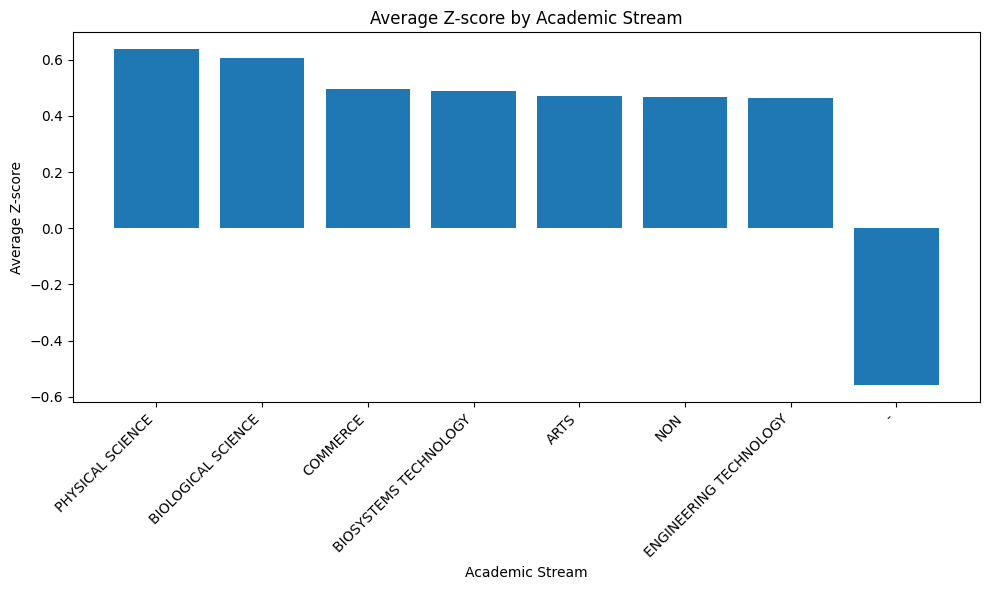

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    rollup_stream["stream_name"],
    rollup_stream["average_z_score"]
)

plt.xlabel("Academic Stream")
plt.ylabel("Average Z-score")
plt.title("Average Z-score by Academic Stream")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

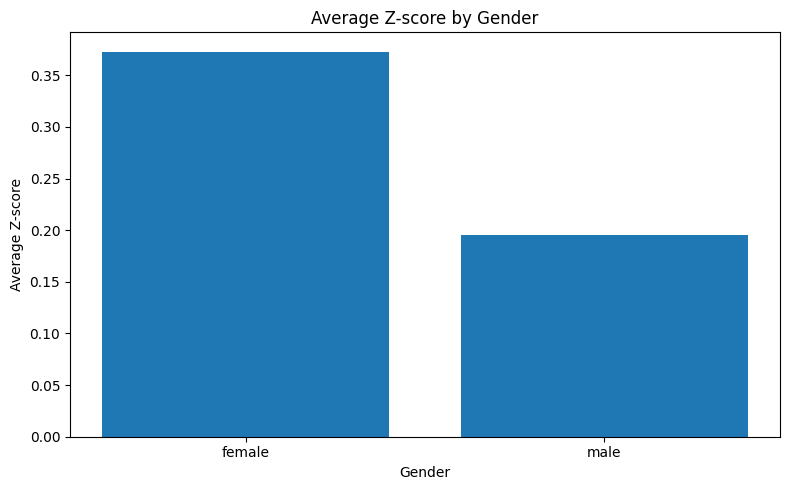

In [17]:
gender_chart = gender_performance[
    gender_performance["gender"].isin(["female", "male"])
]

plt.figure(figsize=(8, 5))

plt.bar(
    gender_chart["gender"],
    gender_chart["average_z_score"]
)

plt.xlabel("Gender")
plt.ylabel("Average Z-score")
plt.title("Average Z-score by Gender")

plt.tight_layout()
plt.show()

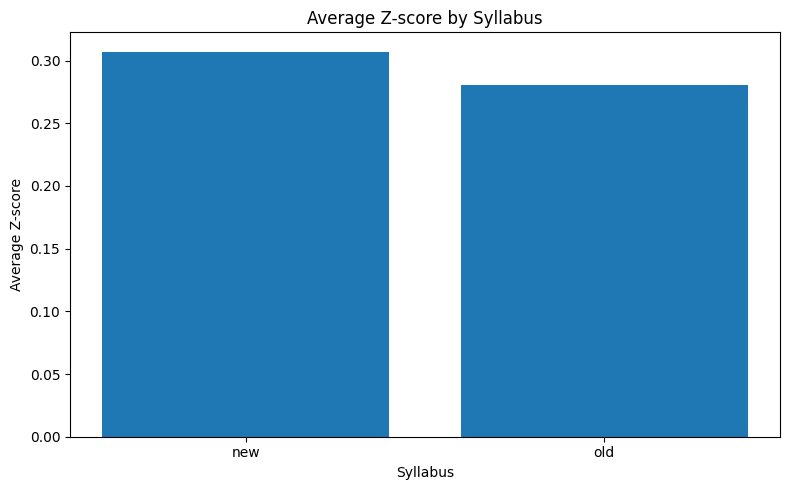

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(
    syllabus_performance["syllabus_name"],
    syllabus_performance["average_z_score"]
)

plt.xlabel("Syllabus")
plt.ylabel("Average Z-score")
plt.title("Average Z-score by Syllabus")

plt.tight_layout()
plt.show()

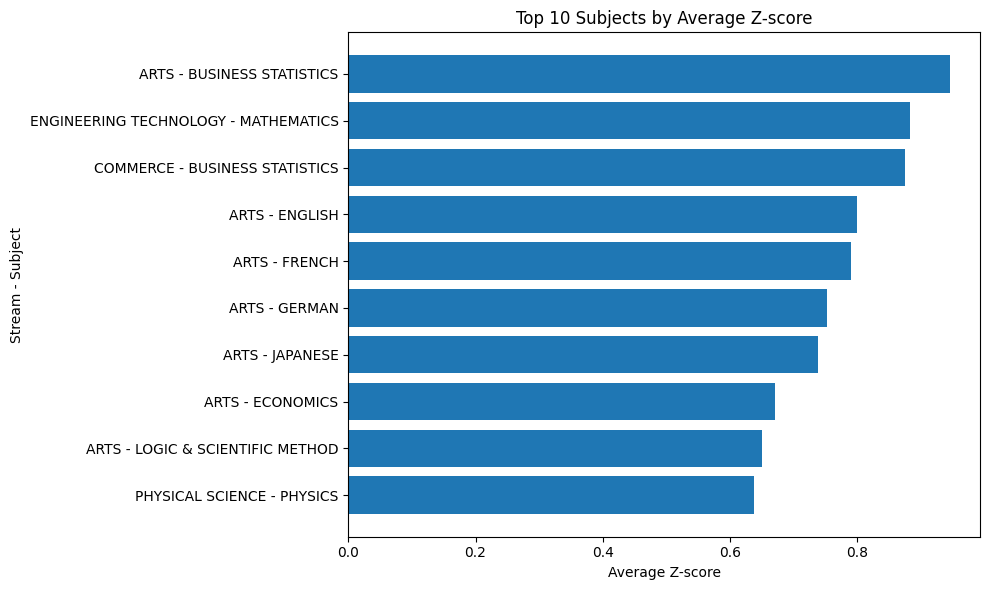

In [19]:
top10 = top_subjects.head(10).copy()

top10["label"] = (
    top10["stream_name"] + " - " + top10["subject_name"]
)

top10 = top10.sort_values("average_z_score")

plt.figure(figsize=(10, 6))

plt.barh(
    top10["label"],
    top10["average_z_score"]
)

plt.xlabel("Average Z-score")
plt.ylabel("Stream - Subject")
plt.title("Top 10 Subjects by Average Z-score")

plt.tight_layout()
plt.show()

In [20]:
print("===== OLAP CUBE VALIDATION =====")

print("Fact table rows:", len(fact_student_subject))
print("Cube data rows:", len(cube_data))

print("Distinct students:", cube_data["student_key"].nunique())
print("Subjects:", cube_data["subject_name"].nunique())
print("Streams:", cube_data["stream_name"].nunique())
print("Syllabuses:", cube_data["syllabus_name"].nunique())
print("Exam years:", cube_data["exam_year"].nunique())

print("\nValidation:")
print("Fact rows = Cube rows:", len(fact_student_subject) == len(cube_data))
print("Expected students:", cube_data["student_key"].nunique() == 337553)
print("Expected subjects:", cube_data["subject_name"].nunique() == 62)
print("Expected streams:", cube_data["stream_name"].nunique() == 8)
print("Expected syllabuses:", cube_data["syllabus_name"].nunique() == 2)

===== OLAP CUBE VALIDATION =====
Fact table rows: 1012659
Cube data rows: 1012659
Distinct students: 337553
Subjects: 62
Streams: 8
Syllabuses: 2
Exam years: 1

Validation:
Fact rows = Cube rows: True
Expected students: True
Expected subjects: True
Expected streams: True
Expected syllabuses: True


In [21]:
print("===== MISSING VALUE CHECK =====")

print("Missing Z-scores:", cube_data["Zscore"].isna().sum())
print("Missing Student Keys:", cube_data["student_key"].isna().sum())
print("Missing Subject Names:", cube_data["subject_name"].isna().sum())
print("Missing Stream Names:", cube_data["stream_name"].isna().sum())
print("Missing Syllabus Names:", cube_data["syllabus_name"].isna().sum())
print("Missing Exam Years:", cube_data["exam_year"].isna().sum())
print("Missing Gender:", cube_data["gender"].isna().sum())
print("Missing District Rank:", cube_data["district_rank"].isna().sum())
print("Missing Island Rank:", cube_data["island_rank"].isna().sum())

===== MISSING VALUE CHECK =====
Missing Z-scores: 315747
Missing Student Keys: 0
Missing Subject Names: 0
Missing Stream Names: 0
Missing Syllabus Names: 0
Missing Exam Years: 0
Missing Gender: 4452
Missing District Rank: 459762
Missing Island Rank: 459762


In [22]:
print("===== DUPLICATE FACT CHECK =====")

duplicates = fact_student_subject.duplicated(
    subset=[
        "student_key",
        "subject_key",
        "stream_key",
        "exam_key",
        "syllabus_key"
    ]
).sum()

print("Duplicate fact records:", duplicates)

if duplicates == 0:
    print("Result: PASS - No duplicate fact records found.")
else:
    print("Result: CHECK - Duplicate fact records exist.")

===== DUPLICATE FACT CHECK =====
Duplicate fact records: 0
Result: PASS - No duplicate fact records found.


In [23]:
print("===== MEASURE VALIDATION =====")

print("Average Z-score:", cube_data["Zscore"].mean())
print("Minimum Z-score:", cube_data["Zscore"].min())
print("Maximum Z-score:", cube_data["Zscore"].max())

print("\nOLAP cube contains:")
print("Average Z-score:", olap_cube.size > 0)
print("Stream analysis:", rollup_stream.shape[0] > 0)
print("Subject analysis:", drilldown_subject.shape[0] > 0)
print("Gender analysis:", gender_performance.shape[0] > 0)
print("Syllabus analysis:", syllabus_performance.shape[0] > 0)

print("\nResult: OLAP measure validation completed.")

===== MEASURE VALIDATION =====
Average Z-score: 0.30538889171086153
Minimum Z-score: -1.9383
Maximum Z-score: 3.5583

OLAP cube contains:
Average Z-score: True
Stream analysis: True
Subject analysis: True
Gender analysis: True
Syllabus analysis: True

Result: OLAP measure validation completed.


In [25]:
# ============================================================
# STUDENT PERFORMANCE DATA WAREHOUSE & OLAP REPORT
# Complete PDF Generation Code
# ============================================================

# Install required library
!pip -q install reportlab

import os
import math
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
    KeepTogether
)

# ============================================================
# 1. FILE LOCATION
# ============================================================

output_dir = "/content/olap_report_files"
os.makedirs(output_dir, exist_ok=True)

pdf_path = "/content/Student_Performance_OLAP_Report.pdf"

# ============================================================
# 2. BASIC PROJECT INFORMATION
# ============================================================

PROJECT_TITLE = "Student Performance Data Warehouse and OLAP Analysis"

DATASET_NAME = (
    "Student Performance (GCE AL Exam_2020 - Sri Lanka)"
)

DATA_SOURCE = "Kaggle dataset by Sasika Amarasinghe"

MAIN_BUSINESS_QUESTION = (
    "Which subjects have the highest average Z-score within each "
    "academic stream, and how does performance differ by gender "
    "and syllabus?"
)

# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def safe_value(value, decimals=3):
    """Format numerical values safely."""
    if pd.isna(value):
        return "N/A"

    if isinstance(value, float):
        return f"{value:.{decimals}f}"

    return str(value)


def make_table(data, col_widths=None, header=True):
    """Create a formatted ReportLab table."""

    table = Table(
        data,
        colWidths=col_widths,
        repeatRows=1 if header else 0
    )

    style_commands = [
        (
            "GRID",
            (0, 0),
            (-1, -1),
            0.5,
            colors.grey
        ),
        (
            "VALIGN",
            (0, 0),
            (-1, -1),
            "MIDDLE"
        ),
        (
            "LEFTPADDING",
            (0, 0),
            (-1, -1),
            6
        ),
        (
            "RIGHTPADDING",
            (0, 0),
            (-1, -1),
            6
        ),
        (
            "TOPPADDING",
            (0, 0),
            (-1, -1),
            5
        ),
        (
            "BOTTOMPADDING",
            (0, 0),
            (-1, -1),
            5
        )
    ]

    if header:
        style_commands.extend([
            (
                "BACKGROUND",
                (0, 0),
                (-1, 0),
                colors.HexColor("#2F5597")
            ),
            (
                "TEXTCOLOR",
                (0, 0),
                (-1, 0),
                colors.white
            ),
            (
                "FONTNAME",
                (0, 0),
                (-1, 0),
                "Helvetica-Bold"
            )
        ])

    table.setStyle(TableStyle(style_commands))

    return table


def add_page_number(canvas, doc):
    """Add page number to every page."""

    canvas.saveState()

    canvas.setFont("Helvetica", 8)

    canvas.drawCentredString(
        A4[0] / 2,
        1.0 * cm,
        f"Page {doc.page}"
    )

    canvas.restoreState()


def create_bar_chart(
    x_values,
    y_values,
    title,
    xlabel,
    ylabel,
    filename,
    rotate=False
):
    """Create a simple bar chart."""

    plt.figure(figsize=(9, 5))

    plt.bar(x_values, y_values)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if rotate:
        plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    path = os.path.join(output_dir, filename)

    plt.savefig(
        path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.close()

    return path


# ============================================================
# 4. CREATE CHARTS
# ============================================================

# Chart 1 - Stream performance

chart_stream = create_bar_chart(
    rollup_stream["stream_name"],
    rollup_stream["average_z_score"],
    "Average Z-score by Academic Stream",
    "Academic Stream",
    "Average Z-score",
    "chart_stream.png",
    rotate=True
)


# Chart 2 - Gender performance

gender_chart = gender_performance[
    gender_performance["gender"].isin(["female", "male"])
].copy()

chart_gender = create_bar_chart(
    gender_chart["gender"],
    gender_chart["average_z_score"],
    "Average Z-score by Gender",
    "Gender",
    "Average Z-score",
    "chart_gender.png"
)


# Chart 3 - Syllabus performance

chart_syllabus = create_bar_chart(
    syllabus_performance["syllabus_name"],
    syllabus_performance["average_z_score"],
    "Average Z-score by Syllabus",
    "Syllabus",
    "Average Z-score",
    "chart_syllabus.png"
)


# Chart 4 - Top 10 subjects

top10 = top_subjects.head(10).copy()

top10["label"] = (
    top10["stream_name"]
    + " - "
    + top10["subject_name"]
)

top10 = top10.sort_values(
    "average_z_score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["label"],
    top10["average_z_score"]
)

plt.xlabel("Average Z-score")
plt.ylabel("Stream - Subject")
plt.title("Top 10 Subjects by Average Z-score")

plt.tight_layout()

chart_top10 = os.path.join(
    output_dir,
    "chart_top10_subjects.png"
)

plt.savefig(
    chart_top10,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 5. CALCULATE VALIDATION VALUES
# ============================================================

fact_rows = len(fact_student_subject)

cube_rows = len(cube_data)

distinct_students = cube_data["student_key"].nunique()

subject_count = cube_data["subject_name"].nunique()

stream_count = cube_data["stream_name"].nunique()

syllabus_count = cube_data["syllabus_name"].nunique()

exam_year_count = cube_data["exam_year"].nunique()

duplicate_count = fact_student_subject.duplicated(
    subset=[
        "student_key",
        "subject_key",
        "stream_key",
        "exam_key",
        "syllabus_key"
    ]
).sum()

missing_zscore = cube_data["Zscore"].isna().sum()

missing_gender = cube_data["gender"].isna().sum()

missing_district_rank = cube_data[
    "district_rank"
].isna().sum()

missing_island_rank = cube_data[
    "island_rank"
].isna().sum()

average_zscore = cube_data["Zscore"].mean()

minimum_zscore = cube_data["Zscore"].min()

maximum_zscore = cube_data["Zscore"].max()


# ============================================================
# 6. FINDINGS
# ============================================================

highest_stream = rollup_stream.iloc[0]

lowest_stream = rollup_stream.iloc[-1]

highest_gender = gender_chart.iloc[
    gender_chart["average_z_score"].argmax()
]

highest_syllabus = syllabus_performance.iloc[0]

lowest_syllabus = syllabus_performance.iloc[-1]

highest_subject = top_subjects.iloc[0]


# ============================================================
# 7. REPORT STYLES
# ============================================================

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "ReportTitle",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=20,
    leading=25,
    alignment=TA_CENTER,
    spaceAfter=15
)

subtitle_style = ParagraphStyle(
    "Subtitle",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=11,
    leading=16,
    alignment=TA_CENTER,
    spaceAfter=10
)

heading_style = ParagraphStyle(
    "Heading",
    parent=styles["Heading1"],
    fontName="Helvetica-Bold",
    fontSize=15,
    leading=19,
    spaceBefore=12,
    spaceAfter=8
)

subheading_style = ParagraphStyle(
    "SubHeading",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=12,
    leading=15,
    spaceBefore=8,
    spaceAfter=6
)

body_style = ParagraphStyle(
    "Body",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9.5,
    leading=14,
    alignment=TA_LEFT,
    spaceAfter=7
)

small_style = ParagraphStyle(
    "Small",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=8,
    leading=11,
    spaceAfter=5
)

center_style = ParagraphStyle(
    "Center",
    parent=body_style,
    alignment=TA_CENTER
)


# ============================================================
# 8. CREATE PDF DOCUMENT
# ============================================================

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=1.5 * cm,
    leftMargin=1.5 * cm,
    topMargin=1.5 * cm,
    bottomMargin=1.5 * cm
)

story = []


# ============================================================
# COVER PAGE
# ============================================================

story.append(Spacer(1, 3 * cm))

story.append(
    Paragraph(
        PROJECT_TITLE,
        title_style
    )
)

story.append(
    Paragraph(
        "Data Warehouse, OLAP Cube and Analytical Report",
        subtitle_style
    )
)

story.append(Spacer(1, 1 * cm))

story.append(
    Paragraph(
        f"<b>Dataset:</b> {DATASET_NAME}",
        center_style
    )
)

story.append(
    Paragraph(
        f"<b>Source:</b> {DATA_SOURCE}",
        center_style
    )
)

story.append(Spacer(1, 1 * cm))

story.append(
    Paragraph(
        "<b>Technology Used</b>",
        subheading_style
    )
)

technology_data = [
    ["Component", "Technology"],
    ["Data Processing / ETL", "Python / Pandas / Google Colab"],
    ["Data Warehouse", "PostgreSQL"],
    ["Database Management", "pgAdmin"],
    ["OLAP Analysis", "Python / Pandas"],
    ["Visualizations", "Matplotlib"],
]
story.append(
    make_table(
        technology_data,
        col_widths=[7 * cm, 9 * cm]
    )
)

story.append(Spacer(1, 1 * cm))

story.append(
    Paragraph(
        "This report documents the complete six-step OLAP "
        "development process, from business requirements and "
        "data source identification to cube construction, "
        "analytical operations, visualization and validation.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 1. BUSINESS REQUIREMENTS
# ============================================================

story.append(
    Paragraph(
        "1. Define the Business Requirements",
        heading_style
    )
)

story.append(
    Paragraph(
        "The purpose of the OLAP solution is to analyse Sri Lankan "
        "GCE Advanced Level student performance and identify "
        "performance patterns across academic streams, subjects, "
        "gender groups and syllabuses.",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Main Business Question</b>",
        subheading_style
    )

)

story.append(
    Paragraph(
        MAIN_BUSINESS_QUESTION,
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Supporting Analytical Questions</b>",
        subheading_style
    )
)

questions = [
    "Which academic stream has the highest average Z-score?",
    "Which subjects have the highest average Z-scores?",
    "How does student performance differ between female and male students?",
    "Does average performance differ between the new and old syllabuses?",
    "How many students are represented in each academic stream?",
    "What are the average district and island ranks?"
]

for q in questions:
    story.append(
        Paragraph(
            "• " + q,
            body_style
        )
    )

story.append(
    Paragraph(
        "<b>Relevant Dimensions</b>",
        subheading_style
    )
)

dimension_data = [
    ["Dimension", "Purpose"],
    ["Student", "Student identity, gender and birth date"],
    ["Subject", "Subject-level performance analysis"],
    ["Stream", "Academic stream comparison"],
    ["Exam", "Exam year analysis"],
    ["Syllabus", "New versus old syllabus comparison"],
]

story.append(
    make_table(
        dimension_data,
        col_widths=[5 * cm, 11 * cm]
    )
)

story.append(PageBreak())


# ============================================================
# 2. DATA SOURCE
# ============================================================

story.append(
    Paragraph(
        "2. Identify the Data Source",
        heading_style
    )
)

story.append(
    Paragraph(
        f"The source dataset is <b>{DATASET_NAME}</b>, "
        f"obtained from {DATA_SOURCE}. The dataset contains "
        "student-level GCE Advanced Level examination information.",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Original Dataset</b>",
        subheading_style
    )
)

original_data = [
    ["Property", "Value"],
    ["Original rows", "337,553"],
    ["Original columns", "19"],
    ["Examination year", "2020"],
    ["Subjects per student", "3"],
]

story.append(
    make_table(
        original_data,
        col_widths=[7 * cm, 9 * cm]
    )
)

story.append(Spacer(1, 0.4 * cm))

story.append(
    Paragraph(
        "<b>ETL / Data Transformation</b>",
        subheading_style
    )
)

etl_points = [
    "Text values were cleaned and stripped.",
    "Z-score, district rank and island rank were converted to appropriate numeric types.",
    "Birth day, month and year were combined into a birth_date field.",
    "Subject-specific columns were transformed into a subject-performance structure.",
    "Missing values were retained where they represented missing source information.",
    "The transformed subject-level dataset contains 1,012,659 fact records."
]

for point in etl_points:
    story.append(
        Paragraph(
            "• " + point,
            body_style
        )
    )

story.append(PageBreak())


# ============================================================
# 3. DIMENSIONS AND HIERARCHIES
# ============================================================

story.append(
    Paragraph(
        "3. Define Dimensions and Hierarchies",
        heading_style
    )
)

story.append(
    Paragraph(
        "A star schema was designed for the data warehouse. "
        "The central fact table stores student-subject performance, "
        "while dimension tables provide the descriptive context "
        "required for OLAP analysis.",
        body_style
    )
)

dimension_hierarchy_data = [
    ["Dimension", "Hierarchy / Level", "Records"],
    ["Student", "Student → Gender", "337,553"],
    ["Subject", "Subject", "62"],
    ["Stream", "Stream", "8"],
    ["Exam", "Year", "1"],
    ["Syllabus", "Syllabus", "2"],
]

story.append(
    make_table(
        dimension_hierarchy_data,
        col_widths=[4 * cm, 7 * cm, 5 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Paragraph(
        "<b>Star Schema</b>",
        subheading_style
    )
)

story.append(
    Paragraph(
        "The fact_student_subject table is the central fact table. "
        "It is connected to dim_student, dim_subject, dim_stream, "
        "dim_exam and dim_syllabus through foreign keys.",
        body_style
    )
)

star_schema_text = """
DIM_STUDENT
      |
      |
DIM_SUBJECT ---- FACT_STUDENT_SUBJECT ---- DIM_STREAM
                      |
                      |
                DIM_EXAM
                      |
                      |
                DIM_SYLLABUS
"""

story.append(
    Paragraph(
        "<font name='Courier'>" +
        star_schema_text.replace("\n", "<br/>") +
        "</font>",
        center_style
    )
)

story.append(PageBreak())


# ============================================================
# 4. FACTS AND MEASURES
# ============================================================

story.append(
    Paragraph(
        "4. Choose Facts / Measures",
        heading_style
    )
)

story.append(
    Paragraph(
        "The grain of the fact table is <b>one row per student "
        "per subject performance</b>. Quantitative attributes "
        "were selected as measures for analytical calculations.",
        body_style
    )
)

measure_data = [
    ["Measure", "Aggregation", "Purpose"],
    ["Z-score", "Average", "Main performance indicator"],
    ["District Rank", "Average", "Compare district-level ranking"],
    ["Island Rank", "Average", "Compare national/island ranking"],
    ["Student Count", "Distinct Count", "Measure participation"],
    ["Grade", "Count", "Analyse grade distribution"],
]

story.append(
    make_table(
        measure_data,
        col_widths=[4 * cm, 4 * cm, 8 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Paragraph(
        "<b>Important Measure Handling</b>",
        subheading_style
    )
)

story.append(
    Paragraph(
        "Z-score is the main numerical performance measure and "
        "is aggregated using the average. District Rank and Island "
        "Rank can also be averaged for comparative analysis. "
        "Student Count is calculated using distinct student keys. "
        "Grade is categorical rather than numerical, therefore "
        "grade values are counted instead of averaged.",
        body_style
    )
)

story.append(
    Paragraph(
        f"The overall average Z-score in the fact data is "
        f"<b>{average_zscore:.4f}</b>, with a minimum of "
        f"<b>{minimum_zscore:.4f}</b> and a maximum of "
        f"<b>{maximum_zscore:.4f}</b>.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 5. BUILD AND POPULATE THE CUBE
# ============================================================

story.append(
    Paragraph(
        "5. Build and Populate the OLAP Cube",
        heading_style
    )
)

story.append(
    Paragraph(
        "The PostgreSQL star schema was loaded into Google Colab "
        "using Pandas. The fact table was joined with all five "
        "dimension tables to create an analytical dataset.",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>Cube Construction</b>",
        subheading_style
    )
)

cube_code = """
cube_data =
    fact_student_subject
    + dim_student
    + dim_subject
    + dim_stream
    + dim_exam
    + dim_syllabus

OLAP cube:
    index = Stream + Subject
    columns = Gender + Syllabus
    measure = Average Z-score
"""

story.append(
    Paragraph(
        "<font name='Courier'>" +
        cube_code.replace("\n", "<br/>") +
        "</font>",
        body_style
    )
)

story.append(
    Paragraph(
        "The resulting Pandas OLAP cube contains 215 rows and "
        "6 gender/syllabus combinations. Missing combinations "
        "are represented as NaN values because there are no "
        "records for those particular dimension combinations.",
        body_style
    )
)

story.append(
    Paragraph(
        "<b>OLAP Operations Implemented</b>",
        subheading_style
    )
)

operations = [
    ["Operation", "Implementation"],
    ["Roll-up", "Stream-level performance"],
    ["Drill-down", "Stream → Subject performance"],
    ["Slice", "Physical Science stream"],
    ["Dice", "Physical + Biological Science, Female + Male, New + Old"],
]

story.append(
    make_table(
        operations,
        col_widths=[4 * cm, 12 * cm]
    )
)

story.append(PageBreak())


# ============================================================
# 6. OLAP ANALYSIS - ROLL-UP
# ============================================================

story.append(
    Paragraph(
        "6. OLAP Analysis Results",
        heading_style
    )
)

story.append(
    Paragraph(
        "6.1 Roll-up: Average Z-score by Academic Stream",
        subheading_style
    )
)

story.append(
    Paragraph(
        "Roll-up summarizes detailed student-subject records "
        "at the academic stream level.",
        body_style
    )
)

stream_table = [
    ["Stream", "Average Z-score", "Student Count"]
]

for _, row in rollup_stream.iterrows():
    stream_table.append([
        str(row["stream_name"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        stream_table,
        col_widths=[7 * cm, 4.5 * cm, 4.5 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Image(
        chart_stream,
        width=16 * cm,
        height=9 * cm
    )
)

story.append(
    Paragraph(
        f"The highest average Z-score among the listed streams "
        f"is observed for <b>{highest_stream['stream_name']}</b> "
        f"with an average of "
        f"<b>{highest_stream['average_z_score']:.4f}</b>.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 7. DRILL-DOWN
# ============================================================

story.append(
    Paragraph(
        "6.2 Drill-down: Stream to Subject",
        subheading_style
    )
)

story.append(
    Paragraph(
        "Drill-down moves from a higher-level stream view to "
        "subject-level performance. This allows detailed "
        "investigation of subjects within each stream.",
        body_style
    )
)

drill_sample = drilldown_subject.head(20)

drill_table = [
    [
        "Stream",
        "Subject",
        "Average Z-score",
        "Students"
    ]
]

for _, row in drill_sample.iterrows():
    drill_table.append([
        str(row["stream_name"]),
        str(row["subject_name"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        drill_table,
        col_widths=[4.5 * cm, 5.5 * cm, 3 * cm, 3 * cm]
    )
)

story.append(
    Paragraph(
        "The detailed drill-down result contains "
        f"<b>{len(drilldown_subject):,}</b> stream-subject "
        "combinations.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 8. SLICE
# ============================================================

story.append(
    Paragraph(
        "6.3 Slice: Physical Science",
        subheading_style
    )
)

story.append(
    Paragraph(
        "A slice selects one value from a dimension. In this "
        "analysis, the cube was sliced to the "
        "<b>PHYSICAL SCIENCE</b> stream.",
        body_style
    )
)

slice_table = [
    ["Subject", "Average Z-score", "Student Count"]
]

for _, row in physical_science_slice.iterrows():
    slice_table.append([
        str(row["subject_name"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        slice_table,
        col_widths=[8 * cm, 4 * cm, 4 * cm]
    )
)

story.append(
    Paragraph(
        "The three Physical Science subjects have the same "
        "average Z-score in this dataset. This reflects the "
        "structure of the source data and has not been artificially "
        "changed.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 9. DICE
# ============================================================

story.append(
    Paragraph(
        "6.4 Dice: Multiple Dimension Filters",
        subheading_style
    )
)

story.append(
    Paragraph(
        "The dice operation selects multiple values across "
        "several dimensions. The analysis uses Physical Science "
        "and Biological Science streams, female and male genders, "
        "and new and old syllabuses.",
        body_style
    )
)

dice_table = [
    [
        "Stream",
        "Gender",
        "Syllabus",
        "Average Z-score",
        "Students"
    ]
]

for _, row in dice_result.iterrows():
    dice_table.append([
        str(row["stream_name"]),
        str(row["gender"]),
        str(row["syllabus_name"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        dice_table,
        col_widths=[
            4.5 * cm,
            3 * cm,
            3 * cm,
            3 * cm,
            2.5 * cm
        ]
    )
)

story.append(PageBreak())


# ============================================================
# 10. GENDER ANALYSIS
# ============================================================

story.append(
    Paragraph(
        "7. Gender Performance Analysis",
        heading_style
    )
)

story.append(
    Paragraph(
        "Gender performance was analysed using average Z-score "
        "and distinct student count. The 'major error' source "
        "category was not included in the meaningful female/male "
        "comparison because it contains only 24 records and "
        "represents a data-quality category rather than a gender.",
        body_style
    )
)

gender_table = [
    ["Gender", "Average Z-score", "Student Count"]
]

for _, row in gender_chart.iterrows():
    gender_table.append([
        str(row["gender"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        gender_table,
        col_widths=[6 * cm, 5 * cm, 5 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Image(
        chart_gender,
        width=14 * cm,
        height=9 * cm
    )
)

story.append(
    Paragraph(
        f"Among the female and male categories, "
        f"<b>{highest_gender['gender']}</b> has the higher "
        f"average Z-score at "
        f"<b>{highest_gender['average_z_score']:.4f}</b>.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 11. SYLLABUS ANALYSIS
# ============================================================

story.append(
    Paragraph(
        "8. Syllabus Performance Analysis",
        heading_style
    )
)

syllabus_table = [
    ["Syllabus", "Average Z-score", "Student Count"]
]

for _, row in syllabus_performance.iterrows():
    syllabus_table.append([
        str(row["syllabus_name"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        syllabus_table,
        col_widths=[6 * cm, 5 * cm, 5 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Image(
        chart_syllabus,
        width=14 * cm,
        height=9 * cm
    )
)

story.append(
    Paragraph(
        f"The <b>{highest_syllabus['syllabus_name']}</b> syllabus "
        f"has the higher average Z-score of "
        f"<b>{highest_syllabus['average_z_score']:.4f}</b>, "
        f"compared with "
        f"<b>{lowest_syllabus['average_z_score']:.4f}</b> "
        f"for the {lowest_syllabus['syllabus_name']} syllabus.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 12. TOP SUBJECTS
# ============================================================

story.append(
    Paragraph(
        "9. Top Subject Performance",
        heading_style
    )
)

story.append(
    Paragraph(
        "To avoid misleading conclusions from subjects with very "
        "small numbers of students, subjects were filtered to "
        "include at least 100 students before identifying the "
        "highest average Z-scores.",
        body_style
    )
)

subject_table = [
    [
        "Stream",
        "Subject",
        "Average Z-score",
        "Students"
    ]
]

for _, row in top_subjects.iterrows():
    subject_table.append([
        str(row["stream_name"]),
        str(row["subject_name"]),
        safe_value(row["average_z_score"]),
        f"{int(row['student_count']):,}"
    ])

story.append(
    make_table(
        subject_table,
        col_widths=[4.5 * cm, 5.5 * cm, 3 * cm, 3 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Image(
        chart_top10,
        width=16 * cm,
        height=10 * cm
    )
)

story.append(
    Paragraph(
        f"The highest result among the filtered subject groups "
        f"is <b>{highest_subject['subject_name']}</b> in the "
        f"<b>{highest_subject['stream_name']}</b> stream, with "
        f"an average Z-score of "
        f"<b>{highest_subject['average_z_score']:.4f}</b> "
        f"and {int(highest_subject['student_count']):,} students.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 13. VALIDATION AND TESTING
# ============================================================

story.append(
    Paragraph(
        "10. Validate and Test the OLAP Cube",
        heading_style
    )
)

story.append(
    Paragraph(
        "Several validation tests were performed to confirm that "
        "the OLAP cube accurately reflects the underlying data "
        "warehouse and that the analytical operations produce "
        "valid results.",
        body_style
    )
)

validation_table = [
    ["Validation Test", "Result", "Status"],

    [
        "Fact rows = Cube rows",
        f"{fact_rows:,} = {cube_rows:,}",
        "PASS"
    ],

    [
        "Distinct students",
        f"{distinct_students:,}",
        "PASS"
    ],

    [
        "Subjects",
        str(subject_count),
        "PASS"
    ],

    [
        "Streams",
        str(stream_count),
        "PASS"
    ],

    [
        "Syllabuses",
        str(syllabus_count),
        "PASS"
    ],

    [
        "Exam years",
        str(exam_year_count),
        "PASS"
    ],

    [
        "Duplicate fact records",
        str(duplicate_count),
        "PASS"
    ],

    [
        "Missing Student Keys",
        str(cube_data["student_key"].isna().sum()),
        "PASS"
    ],

    [
        "Missing Subject Names",
        str(cube_data["subject_name"].isna().sum()),
        "PASS"
    ],

    [
        "Missing Stream Names",
        str(cube_data["stream_name"].isna().sum()),
        "PASS"
    ],

    [
        "Missing Syllabus Names",
        str(cube_data["syllabus_name"].isna().sum()),
        "PASS"
    ],
]

story.append(
    make_table(
        validation_table,
        col_widths=[7 * cm, 5 * cm, 4 * cm]
    )
)

story.append(Spacer(1, 0.5 * cm))

story.append(
    Paragraph(
        "<b>Missing Source Values</b>",
        subheading_style
    )
)

missing_table = [
    ["Column", "Missing Values"],
    ["Z-score", f"{missing_zscore:,}"],
    ["Gender", f"{missing_gender:,}"],
    ["District Rank", f"{missing_district_rank:,}"],
    ["Island Rank", f"{missing_island_rank:,}"],
]

story.append(
    make_table(
        missing_table,
        col_widths=[8 * cm, 8 * cm]
    )
)

story.append(
    Paragraph(
        "The missing values above originate from the source "
        "dataset. They do not indicate broken dimension joins. "
        "All important dimension keys and descriptive dimension "
        "names used by the cube contain zero missing values.",
        body_style
    )
)

story.append(
    Paragraph(
        f"The duplicate fact-record test returned "
        f"<b>{duplicate_count}</b> duplicates, confirming that "
        "no duplicate student-subject fact records were detected.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 14. OVERALL VALIDATION SUMMARY
# ============================================================

story.append(
    Paragraph(
        "11. Overall OLAP Validation Summary",
        heading_style
    )
)

overall_validation = [
    ["Requirement", "Status"],
    ["Business questions defined", "PASS"],
    ["Data source identified", "PASS"],
    ["Dimensions defined", "PASS"],
    ["Hierarchies defined", "PASS"],
    ["Facts and measures selected", "PASS"],
    ["OLAP cube constructed", "PASS"],
    ["Roll-up implemented", "PASS"],
    ["Drill-down implemented", "PASS"],
    ["Slice implemented", "PASS"],
    ["Dice implemented", "PASS"],
    ["Charts generated", "PASS"],
    ["Cube row-count validation", "PASS"],
    ["Duplicate validation", "PASS"],
    ["Measure validation", "PASS"],
]

story.append(
    make_table(
        overall_validation,
        col_widths=[11 * cm, 5 * cm]
    )
)

story.append(
    Paragraph(
        "The six required OLAP development steps have therefore "
        "been completed successfully.",
        body_style
    )
)

story.append(PageBreak())


# ============================================================
# 15. KEY FINDINGS
# ============================================================

story.append(
    Paragraph(
        "12. Key Findings",
        heading_style
    )
)

findings = [
    f"The Physical Science stream recorded the highest average "
    f"Z-score among the stream categories with a value of "
    f"{highest_stream['average_z_score']:.4f}.",

    f"The new syllabus recorded an average Z-score of "
    f"{highest_syllabus['average_z_score']:.4f}, compared with "
    f"{lowest_syllabus['average_z_score']:.4f} for the old syllabus.",

    f"Female students recorded an average Z-score of "
    f"{gender_chart.loc[gender_chart['gender']=='female', 'average_z_score'].iloc[0]:.4f}, "
    f"while male students recorded "
    f"{gender_chart.loc[gender_chart['gender']=='male', 'average_z_score'].iloc[0]:.4f}.",

    f"The subject-level analysis identified "
    f"{highest_subject['subject_name']} within the "
    f"{highest_subject['stream_name']} stream as the highest "
    f"average-Z-score subject among groups containing at least "
    f"100 students.",

    "The OLAP cube supports analysis from overall stream-level "
    "performance down to individual subject-level performance.",

    "The cube also supports multidimensional comparisons "
    "involving stream, gender and syllabus."
]

for finding in findings:
    story.append(
        Paragraph(
            "• " + finding,
            body_style
        )
    )


# ============================================================
# 16. CONCLUSION
# ============================================================

story.append(
    Paragraph(
        "13. Conclusion",
        heading_style
    )
)

story.append(
    Paragraph(
        "A complete student performance Data Warehouse and OLAP "
        "solution was successfully developed using PostgreSQL, "
        "Python, Pandas and Google Colab. The data was transformed "
        "into a star schema consisting of a central "
        "fact_student_subject table and five dimension tables.",
        body_style
    )
)

story.append(
    Paragraph(
        "The resulting OLAP cube enables multidimensional analysis "
        "of student performance using Z-score, rankings, student "
        "counts and grade distributions. Roll-up, drill-down, "
        "slice and dice operations were implemented successfully.",
        body_style
    )
)

story.append(
    Paragraph(
        "Validation confirmed that the cube contains the expected "
        "number of records and dimensions, contains no duplicate "
        "fact records, and maintains valid dimension relationships. "
        "The analytical results and visualizations demonstrate "
        "that the cube meets the defined business requirements.",
        body_style
    )
)

story.append(Spacer(1, 1 * cm))

story.append(
    Paragraph(
        "<b>Final Status: OLAP CUBE SUCCESSFULLY BUILT, "
        "ANALYSED AND VALIDATED</b>",
        center_style
    )
)


# ============================================================
# 17. BUILD PDF
# ============================================================

doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)

print("=" * 60)
print("PDF REPORT GENERATED SUCCESSFULLY")
print("=" * 60)
print()
print("File:", pdf_path)
print()
print("You can download the PDF from the file link shown below.")

# ============================================================
# AUTO DOWNLOAD PDF
# ============================================================

from google.colab import files

files.download(pdf_path)

PDF REPORT GENERATED SUCCESSFULLY

File: /content/Student_Performance_OLAP_Report.pdf

You can download the PDF from the file link shown below.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>